##**Importing Important Libraries**

In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve
import missingno as msno
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_samples, silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.ensemble import RandomForestClassifier
from mlxtend.evaluate import bias_variance_decomp
from sklearn.model_selection import cross_val_score

##**EDA**

###**Reading The Data**

In [126]:
df = pd.read_csv("/content/german_credit_data.csv")

In [127]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


###**Important Info on the data**

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


###**Number of features and rows**

In [129]:
df.shape

(1000, 10)

we have 10 features

###**Descriptive Analytics on the data**

In [130]:
df.describe().round(2)

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,499.50,35.55,1.90,3271.26,20.90
std,288.82,11.38,0.65,2822.74,12.06
min,0.00,19.00,0.00,250.00,4.00
25%,249.75,27.00,2.00,1365.50,12.00
50%,499.50,33.00,2.00,2319.50,18.00
75%,749.25,42.00,2.00,3972.25,24.00
max,999.00,75.00,3.00,18424.00,72.00


###**Droppin unnecessary feature**

In [131]:
df = df.drop("Unnamed: 0", axis=1)

this was necessary to do at the start so we can start working on the real data

###**Makin Numerical and catagorcal variables**

In [132]:
num_col = df.select_dtypes(include=['int64', 'float64']).columns
cat_col = df.select_dtypes(include=['object']).columns

In [133]:
print("Numerical Columns:", num_col)
print("Categorical Columns:", cat_col)

Numerical Columns: Index(['Age', 'Job', 'Credit amount', 'Duration'], dtype='object')
Categorical Columns: Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='object')


###**Numerical Feature Distribution**

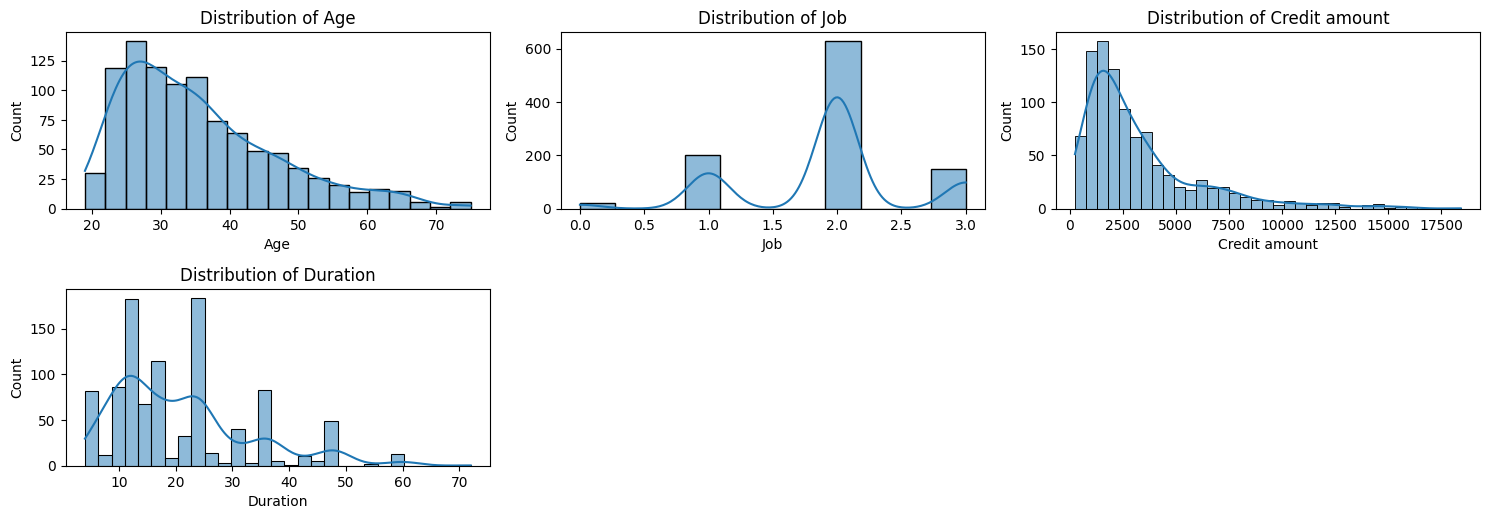

In [134]:
plt.figure(figsize=(15, 10))

for id, name in enumerate(num_col):
    plt.subplot(4, 3, id + 1)
    sns.histplot(df[name], kde=True)
    plt.title(f'Distribution of {name}')

plt.tight_layout()
plt.show()

as we can see the features are not normally distributed so we need to do some transformations on it

###**Categorical Feature Distribution**

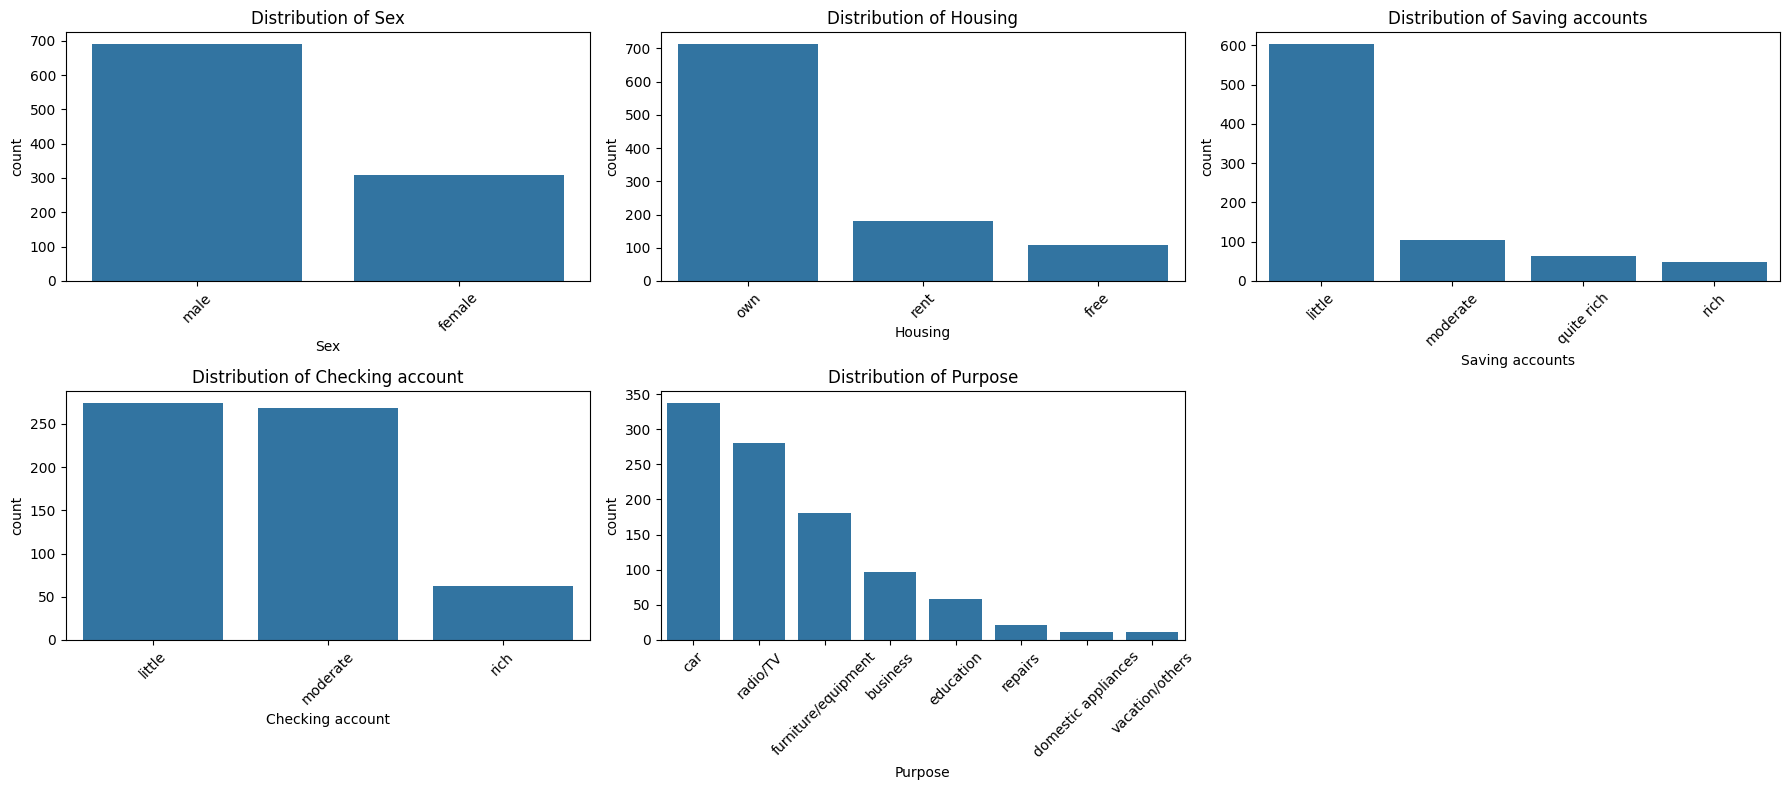

In [135]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    sns.countplot(
        x=df[col],
        order=df[col].value_counts().index,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(cat_col), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

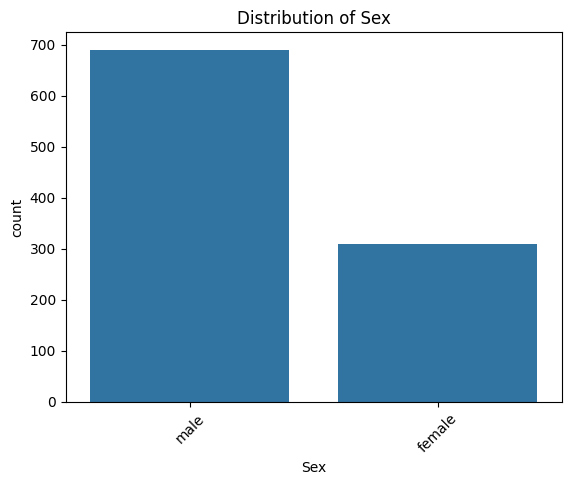

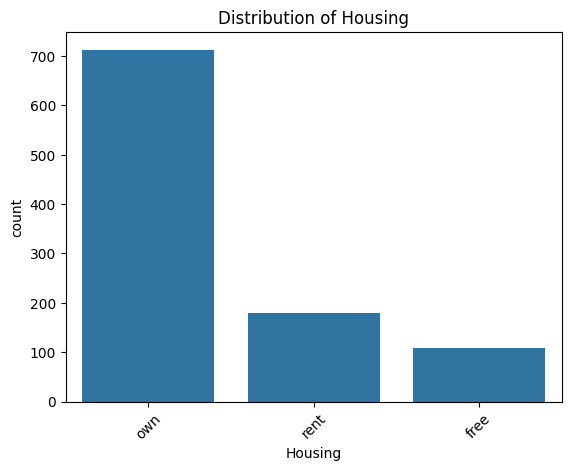

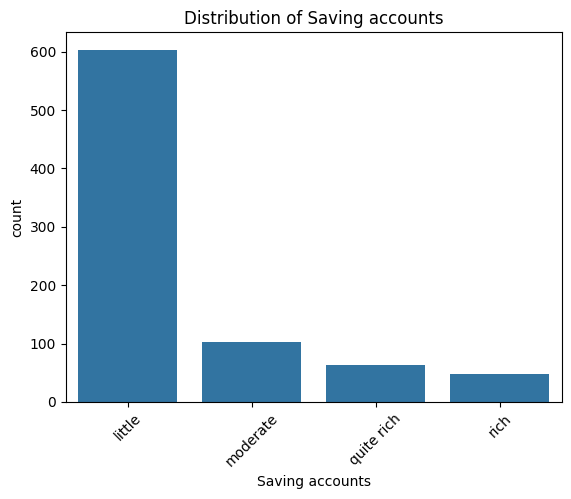

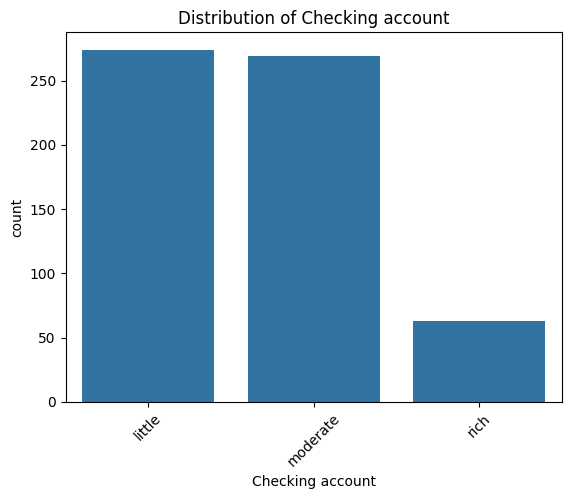

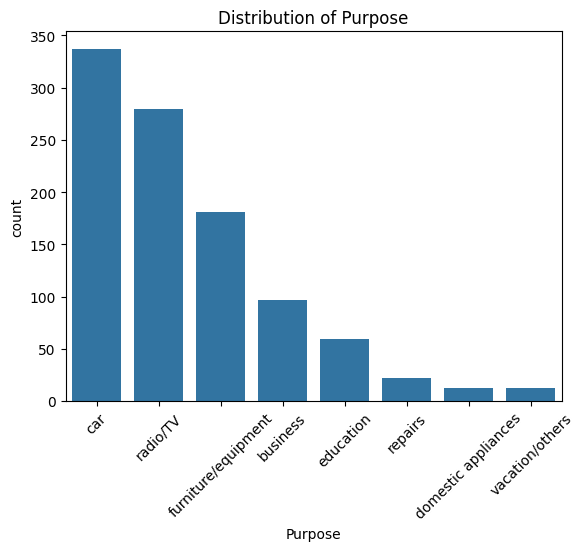

In [136]:
for col in cat_col:
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()


###**Correlation Matrix between numerical features**

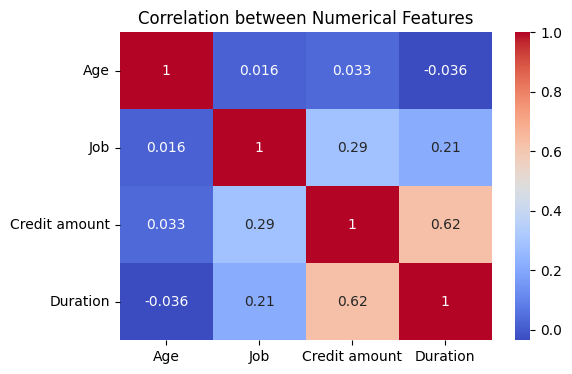

In [137]:
#The relationships between numerical features in the dataset
plt.figure(figsize=(6,4))
sns.heatmap(df[num_col].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between Numerical Features')
plt.show()


The correlation heatmap shows a strong positive relationship between Credit Amount and Duration indicating that higher loans tend to have longer repayment periods. Other features show weak or negligible correlations, suggesting low multicollinearity.

##**Data Preprocessing**

###**Checking for null**

In [138]:
df.isna().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0


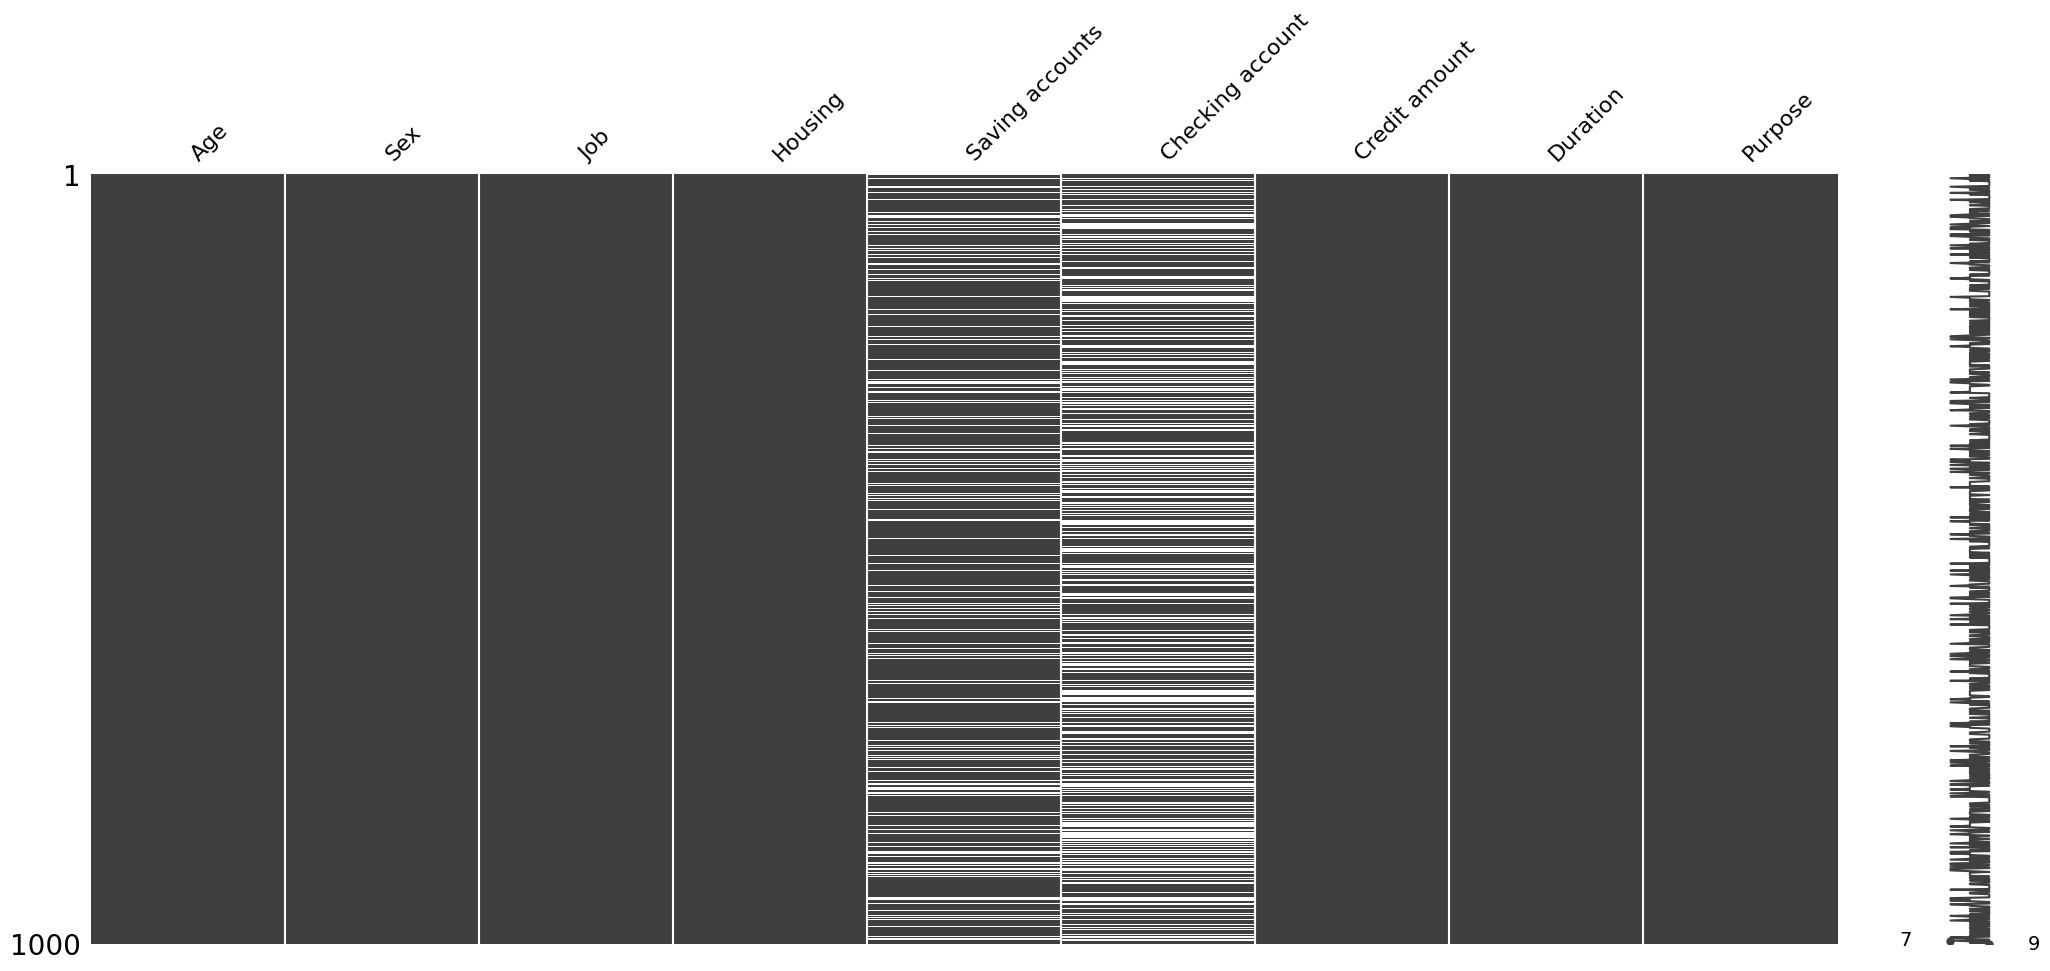

In [139]:
msno.matrix(df)
plt.show()

###**Applying log transformation on features**

In [140]:
df["Age"] = np.log(df["Age"] + 1)
df["Credit amount"] = np.log(df["Credit amount"] + 1)
df["Duration"] = np.log(df["Duration"] + 1)

###**Histogram after transformation**

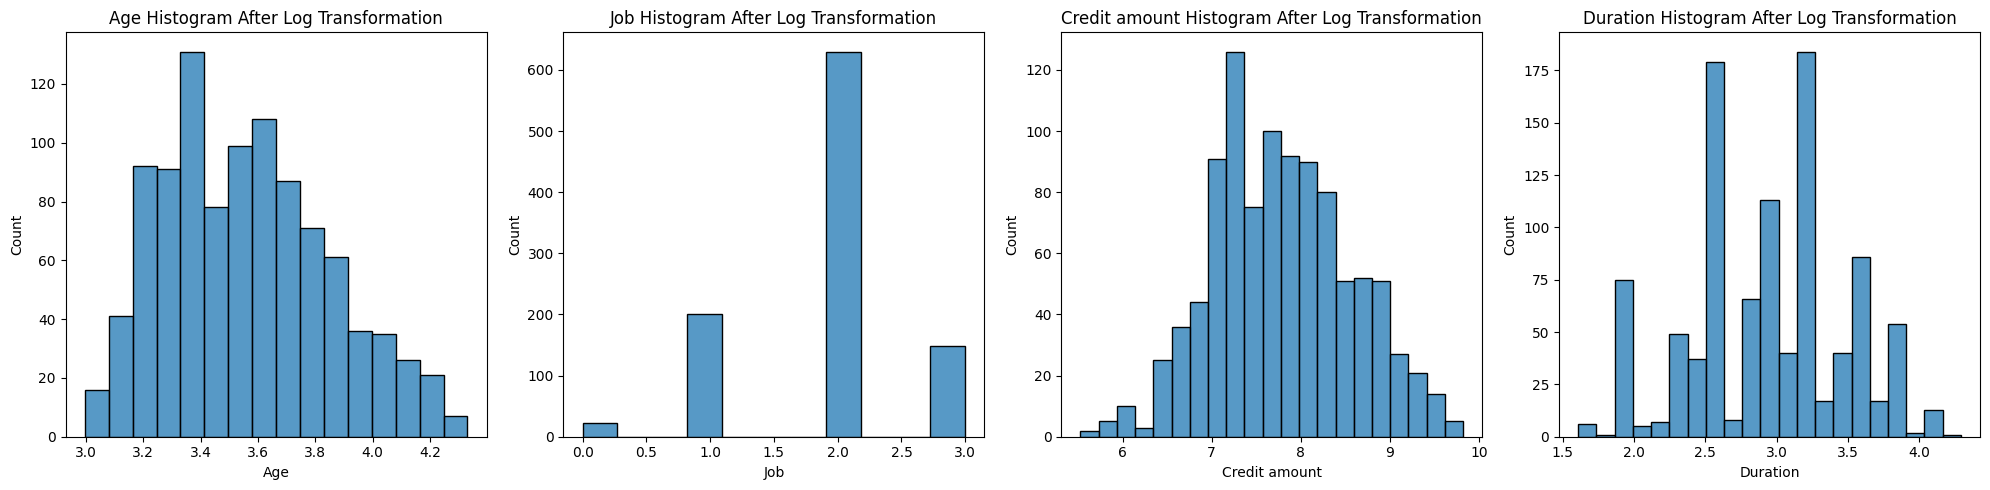

In [141]:
fig, axes = plt.subplots(1, len(num_col), figsize=(5 * len(num_col), 5))

for ax, col in zip(axes, num_col):
    sns.histplot(df[col], ax=ax)
    ax.set_title(f"{col} Histogram After Log Transformation")

plt.tight_layout()
plt.show()

after applying the log transformation the data is more normally distributed so we reduced the skeweness

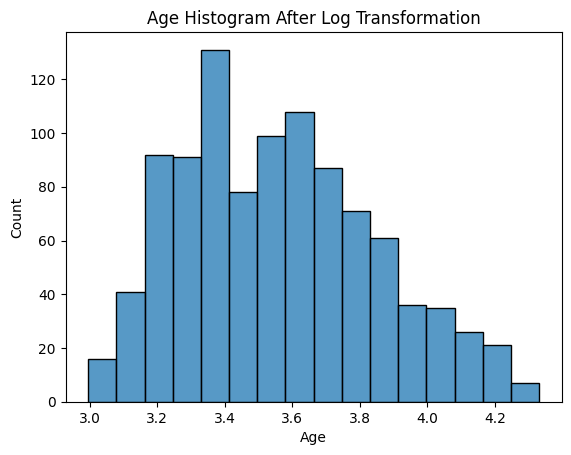

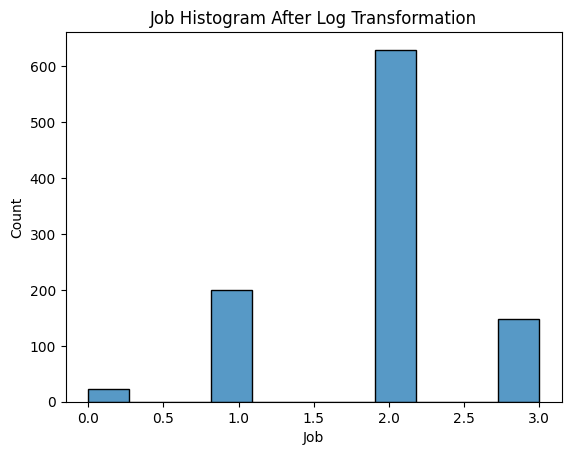

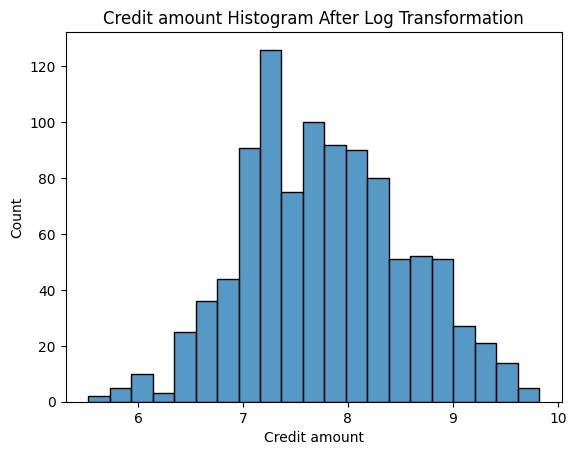

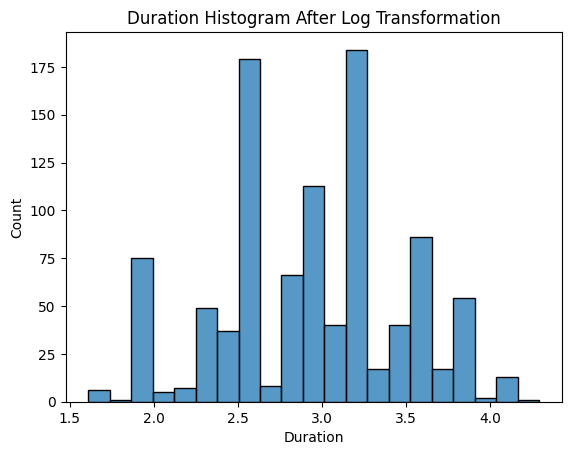

In [142]:
for col in num_col:
    sns.histplot(df[col])
    plt.title(f"{col} Histogram After Log Transformation")
    plt.show()

###**Encoding Categorical Variables**

In [143]:
#Binary encoding for Sex
df["Sex"] = df["Sex"].map({"male": 1, "female": 0})

we applied binary encoding rather than label encoding for gender so we know which feature is which: male --> 1 / female --> 0

In [144]:
# Ordinal encoding for account status variables
df["Saving accounts"] = df["Saving accounts"].map({
    "little": 0, "moderate": 1, "quite rich": 2, "rich": 3
})
df["Checking account"] = df["Checking account"].map({
    "little": 0, "moderate": 1, "rich": 2
})

we used ordinal encoding here because there are levels for each feature:

saving accounts: little --> moderate --> quite rich --> rich

Checking account: little --> moderate --> rich

In [145]:
df = pd.get_dummies(df, columns=["Purpose", "Housing"])

we used one hot encoder with the purpose and housing features

###**Boxplot for numeric features**

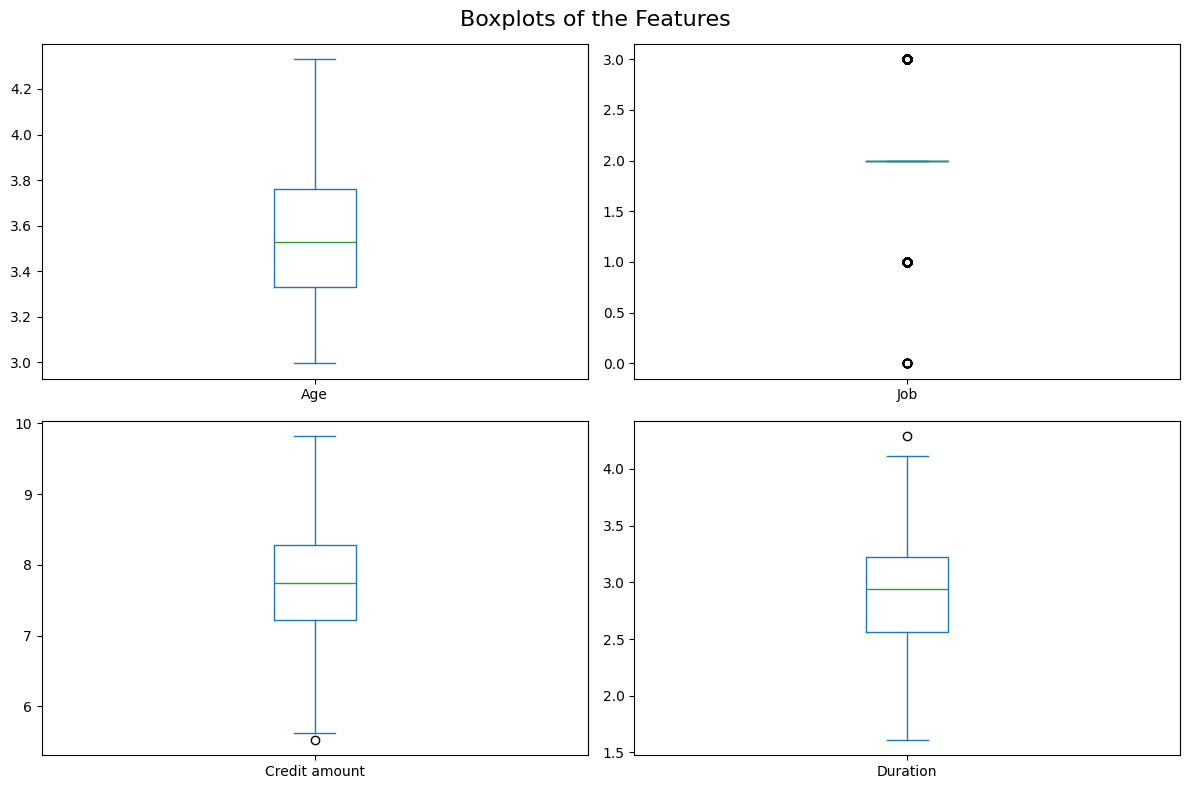

In [146]:
df[num_col].plot(
    kind="box",
    subplots=True,
    layout=(2, 2),
    figsize=(12, 8),
    sharey=False
)

plt.suptitle("Boxplots of the Features", fontsize=16)
plt.tight_layout()
plt.show()

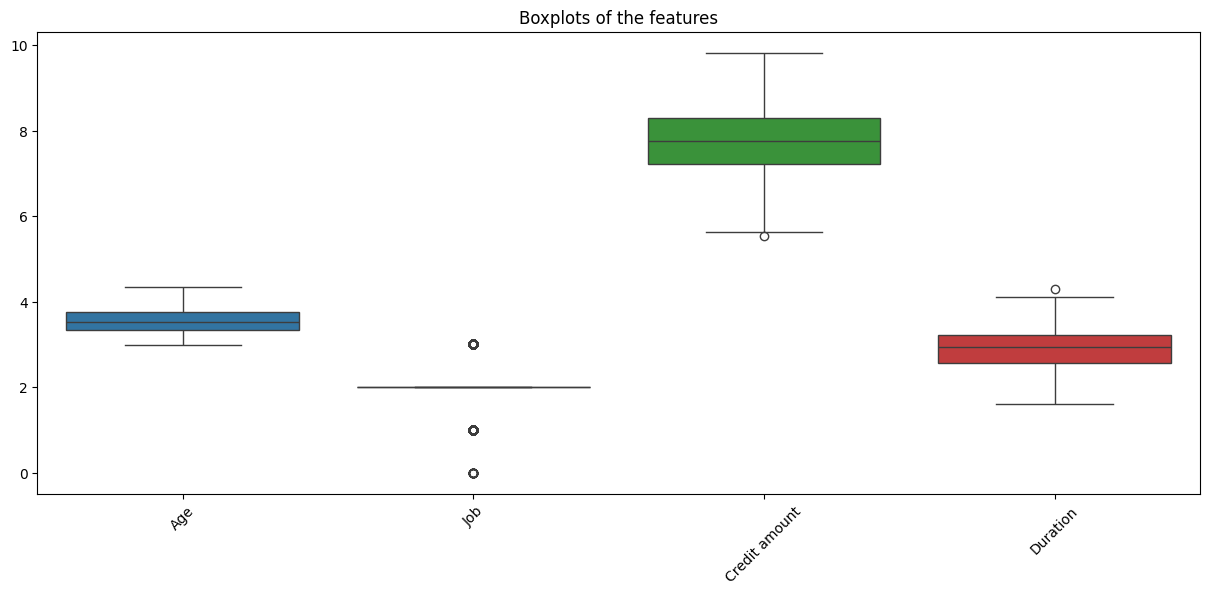

In [147]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df[num_col])
plt.xticks(rotation=45)
plt.title("Boxplots of the features")
plt.show()

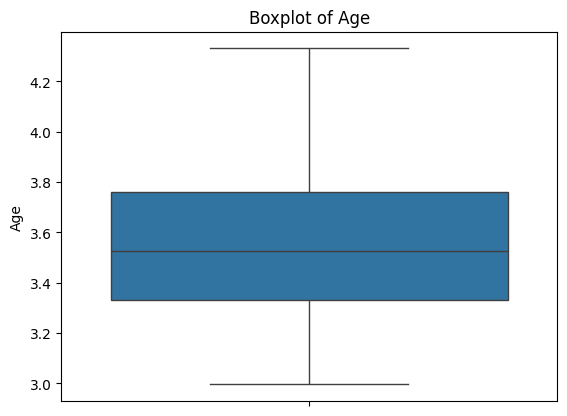

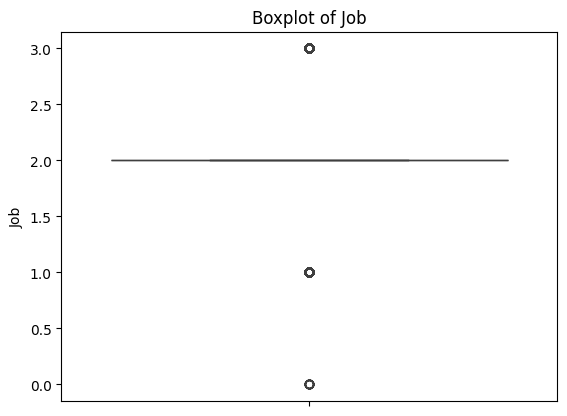

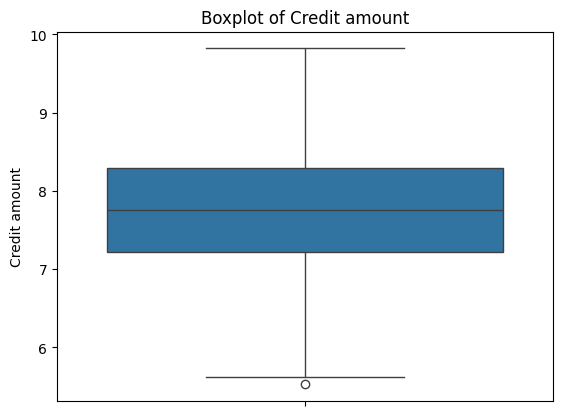

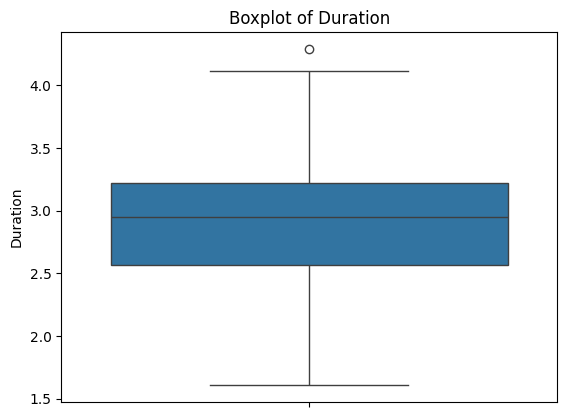

In [148]:
for col in num_col:
    plt.figure()
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

###**Handling Missing Values**

In [149]:
null_cols = [col for col in df.columns if df[col].isnull().sum() > 0]

In [150]:
imputer = SimpleImputer(strategy="most_frequent")
df[null_cols] = imputer.fit_transform(df[null_cols])

using simple imputer with mode strategy to replace missing values with the mode

###**Checking for missing after imputation**

In [151]:
df.isnull().sum()

,0
Age,0
Sex,0
Job,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose_business,0
Purpose_car,0
Purpose_domestic appliances,0


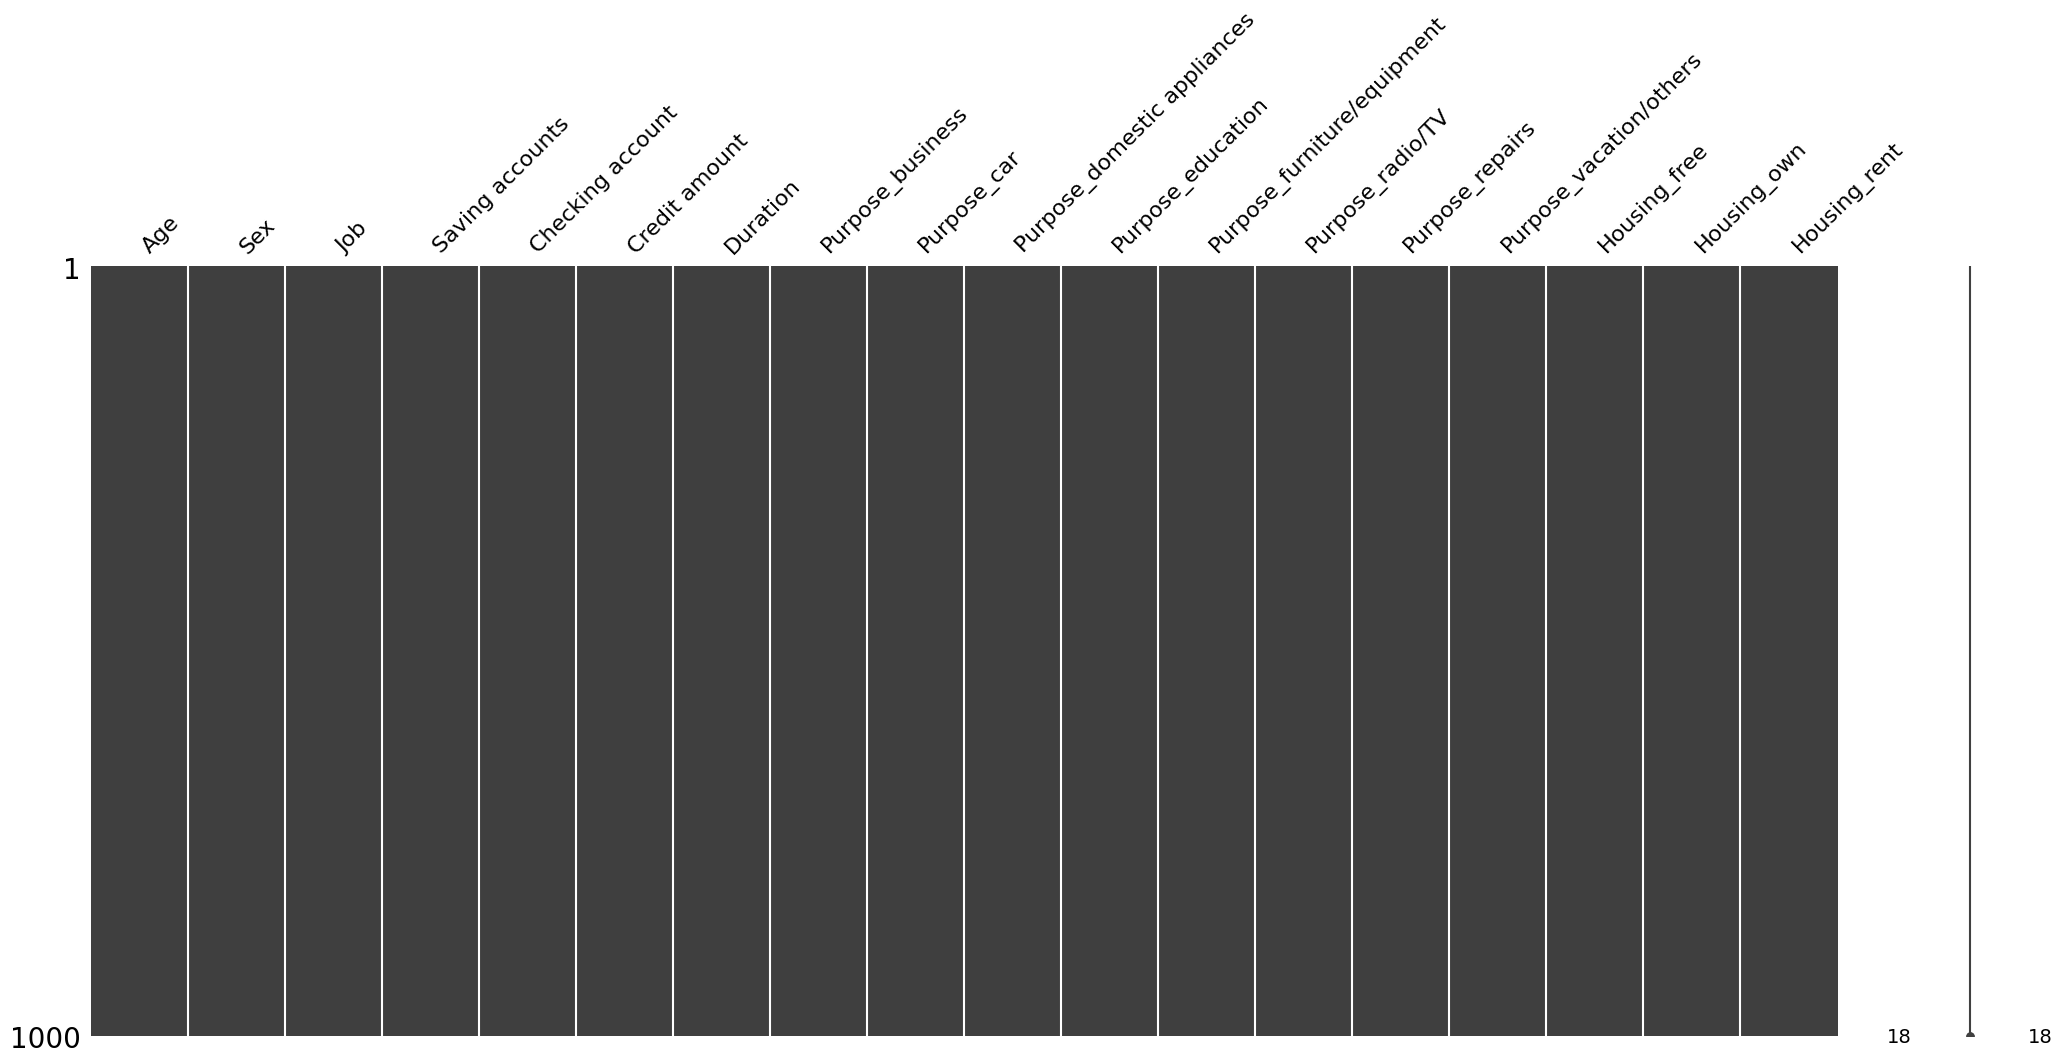

In [152]:
msno.matrix(df)
plt.show()

###**Feature Scaling**

In [153]:
# Feature Scaling
scale_cols = ["Age", "Credit amount", "Duration"]
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

using standard scaler on the numeric variables that need to be scaled because the rest of the features are encoded so they don't need to be scaled

##**K-Means Clustering**

###**Making the k clusters**

In [154]:
# determine optimal number of clusters
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)

###**Using Elbow Method to get the optimal K**

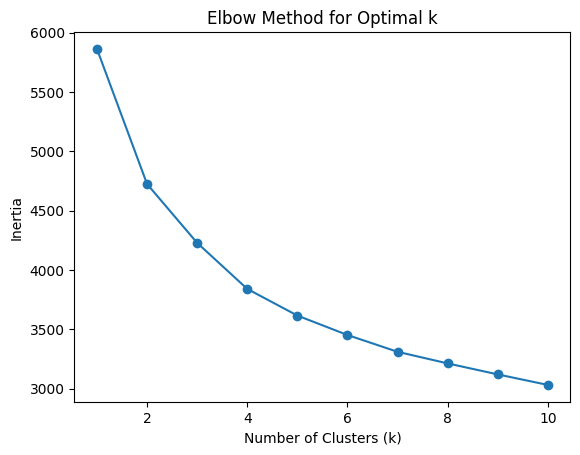

In [155]:
#Elbow curve
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

###**Apply K-Means with Optimal k**

In [156]:
k_values = [2, 3, 4, 5, 6]
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df[f'cluster_k{k}'] = kmeans.fit_predict(df)

###**Checking the silhouettte score of each K**

In [157]:
for k in k_values:
    score = silhouette_score(df, df[f'cluster_k{k}'])
    print(f'k = {k} → Silhouette Score = {score:.3f}')

k = 2 → Silhouette Score = 0.309
k = 3 → Silhouette Score = 0.354
k = 4 → Silhouette Score = 0.409
k = 5 → Silhouette Score = 0.339
k = 6 → Silhouette Score = 0.268


In [158]:
df['cluster'] = df['cluster_k4']

In [159]:
df_new=pd.read_csv(r"/content/german_credit_data.csv")

In [160]:
df_new["cluster"]=df["cluster"]

we made a new dataframe with the old data before preprocessing and added the newly made clusters to it to avoid any data leakage and for easier interpertation for the data before scaling and everything

###**Silhoutte plot**

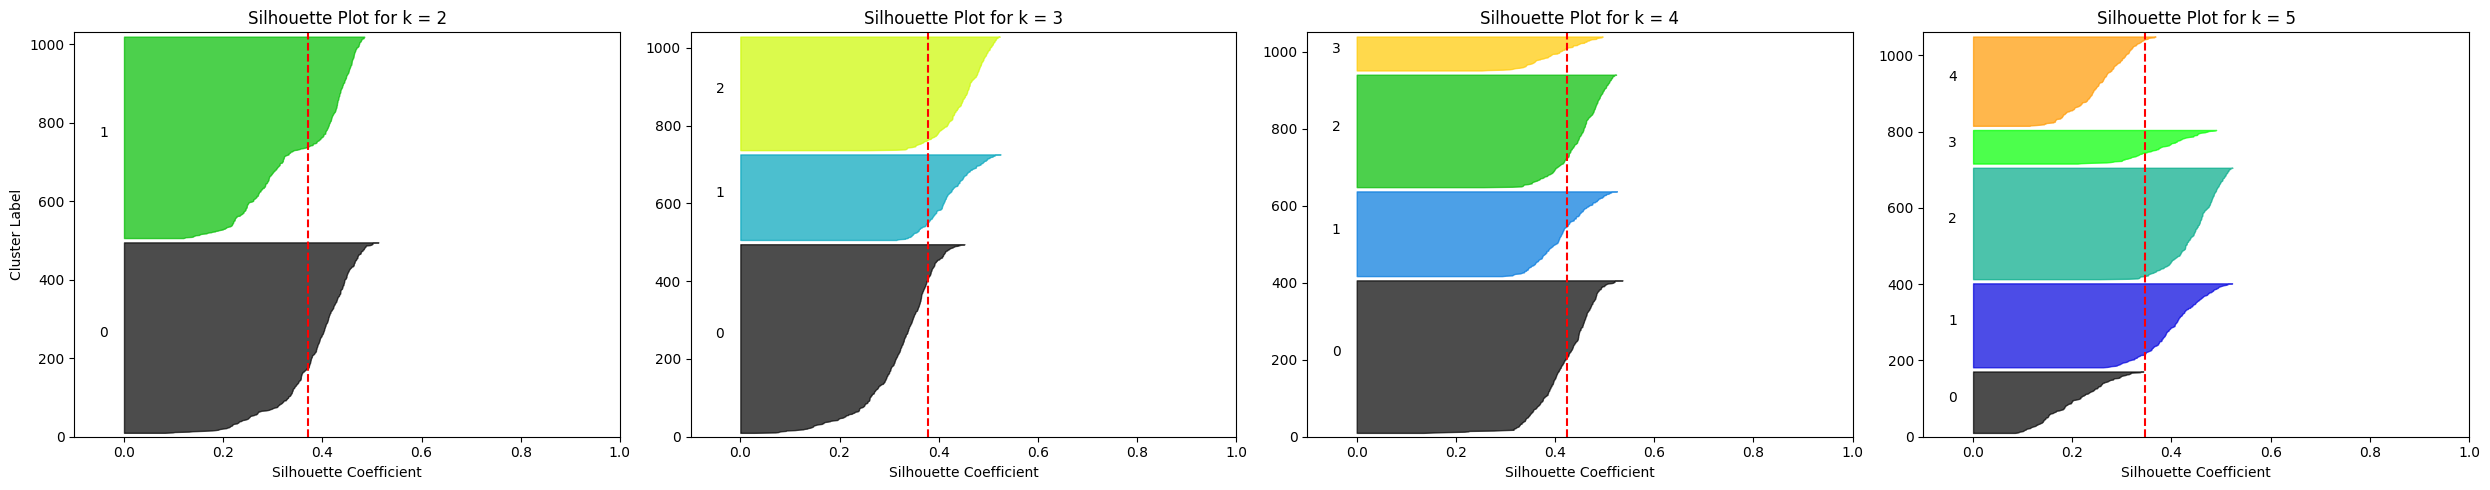

In [161]:
range_n_clusters = [2, 3, 4, 5]

fig, axes = plt.subplots(
    1,
    len(range_n_clusters),
    figsize=(25, 5),
    sharey=False
)

for i, n_clusters in enumerate(range_n_clusters):
    ax = axes[i]

    kmeans = KMeans(
        n_clusters=n_clusters,
        n_init=10,
        random_state=42
    )

    labels = kmeans.fit_predict(df)

    sil_vals = silhouette_samples(df, labels)
    sil_avg = silhouette_score(df, labels)

    y_lower = 10
    for j in range(n_clusters):
        ith_sil_vals = sil_vals[labels == j]
        ith_sil_vals.sort()

        size_j = ith_sil_vals.shape[0]
        y_upper = y_lower + size_j

        color = plt.cm.nipy_spectral(float(j) / n_clusters)

        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_sil_vals,
            facecolor=color,
            edgecolor=color,
            alpha=0.7
        )

        ax.text(-0.05, y_lower + 0.5 * size_j, str(j))
        y_lower = y_upper + 10

    ax.axvline(x=sil_avg, color="red", linestyle="--")
    ax.set_title(f"Silhouette Plot for k = {n_clusters}")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(df) + (n_clusters + 1) * 10])

    if i == 0:
        ax.set_ylabel("Cluster Label")

plt.tight_layout()
plt.show()

###**Checking the cluster size distribution**

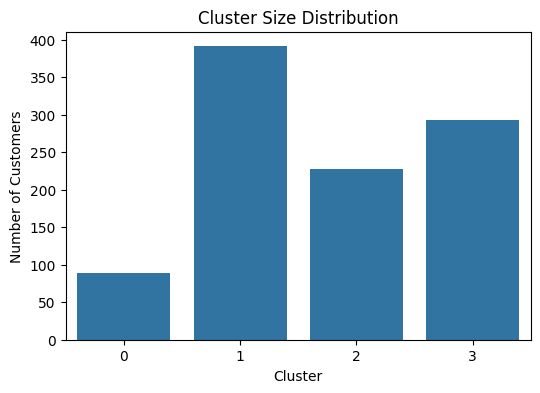

In [162]:
plt.figure(figsize=(6,4))
sns.countplot(x='cluster', data=df_new)
plt.title('Cluster Size Distribution')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.show()

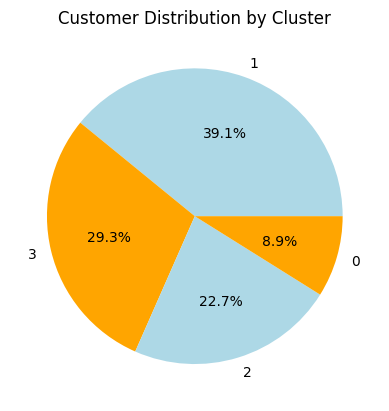

In [163]:
df_new['cluster'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightblue', 'orange'])
plt.title('Customer Distribution by Cluster')
plt.ylabel('')
plt.show()

##**Customer Segementation & Profiling**

###**Profiling**

In [164]:
df_new.groupby('cluster')[['Age', 'Credit amount', 'Duration']].mean()

,Age,Credit amount,Duration
cluster,,,
0,35.988764,2515.359551,19.460674
1,34.877238,5483.312020,31.335038
2,47.488987,1817.039648,12.691630
3,27.051195,1675.590444,13.781570


###**Labeling Each cluster with it's appropriate names**

In [165]:
cluster_names = {
    0: "Mid-Age Moderate Borrowers",
    1: "High-Value Long-Term Borrowers",
    2: "Older Conservative Borrowers",
    3: "Young Low-Credit Borrowers"
}

df_new["cluster_name"] = df_new["cluster"].map(cluster_names)

In [166]:
df_new.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,cluster,cluster_name
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,2,Older Conservative Borrowers
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,1,High-Value Long-Term Borrowers
2,2,49,male,1,own,little,NaN,2096,12,education,2,Older Conservative Borrowers
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,1,High-Value Long-Term Borrowers
4,4,53,male,2,free,little,little,4870,24,car,1,High-Value Long-Term Borrowers


The following table summarizes the characteristics of each cluster along with potential business opportunities derived from the clustering analysis.


###  **Cluster Interpretation and Business Insights**

| Cluster Name | Key Characteristics | Business Opportunities |
|------------|---------------------|------------------------|
| **Balanced Borrowers** | Medium age, medium loan amounts, moderate duration | Upselling opportunities, loyalty programs |
| **High-Value Borrowers** | High loan amounts, long repayment duration | Risk monitoring, premium financial services |
| **Conservative Customers** | Older customers, low loan amounts, short duration | Safe products, savings plans, deposits |
| **Young Borrowers** | Young age, small loan amounts, short duration | Relationship building, future growth potential |


##**Preprocessing and splitting the new dataset**

###**Dropping useless features**

In [167]:
df_new=df_new.drop("Unnamed: 0",axis=1)

###**Spliting the data**

In [168]:
x = df_new.drop("cluster",axis=1)
y = df_new['cluster']

our target variable is the cluster

In [169]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.20,random_state=42)

###**Encoding Categorical Variables**

In [170]:
#Binary encoding for Sex
x_train["Sex"] = x_train["Sex"].map({"male": 1, "female": 0})
x_test["Sex"]  = x_test["Sex"].map({"male": 1, "female": 0})

In [171]:
# Ordinal encoding for account status variables
saving_map = {
    "little": 0,
    "moderate": 1,
    "quite rich": 2,
    "rich": 3
}

checking_map = {
    "little": 0,
    "moderate": 1,
    "rich": 2
}

x_train["Saving accounts"] = x_train["Saving accounts"].map(saving_map)
x_test["Saving accounts"]  = x_test["Saving accounts"].map(saving_map)

x_train["Checking account"] = x_train["Checking account"].map(checking_map)
x_test["Checking account"]  = x_test["Checking account"].map(checking_map)

In [172]:
ohe_col = ["Purpose", "Housing"]

In [173]:
x_train=pd.get_dummies(data=x_train,columns=ohe_col)
x_test=pd.get_dummies(data=x_test,columns=ohe_col)

###**Handling Missing Values**

In [174]:
null_cols = [col for col in x_train.columns if x_train[col].isnull().sum() > 0]

In [175]:
imputer = SimpleImputer(strategy="most_frequent")
x_train[null_cols] = imputer.fit_transform(x_train[null_cols])

In [176]:
x_test[null_cols] = imputer.transform(x_test[null_cols])

###**Checking for missing after imputation**

In [177]:
x_train.isnull().sum()

,0
Age,0
Sex,0
Job,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
cluster_name,0
Purpose_business,0
Purpose_car,0


In [178]:
x_test.isna().sum()

,0
Age,0
Sex,0
Job,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
cluster_name,0
Purpose_business,0
Purpose_car,0


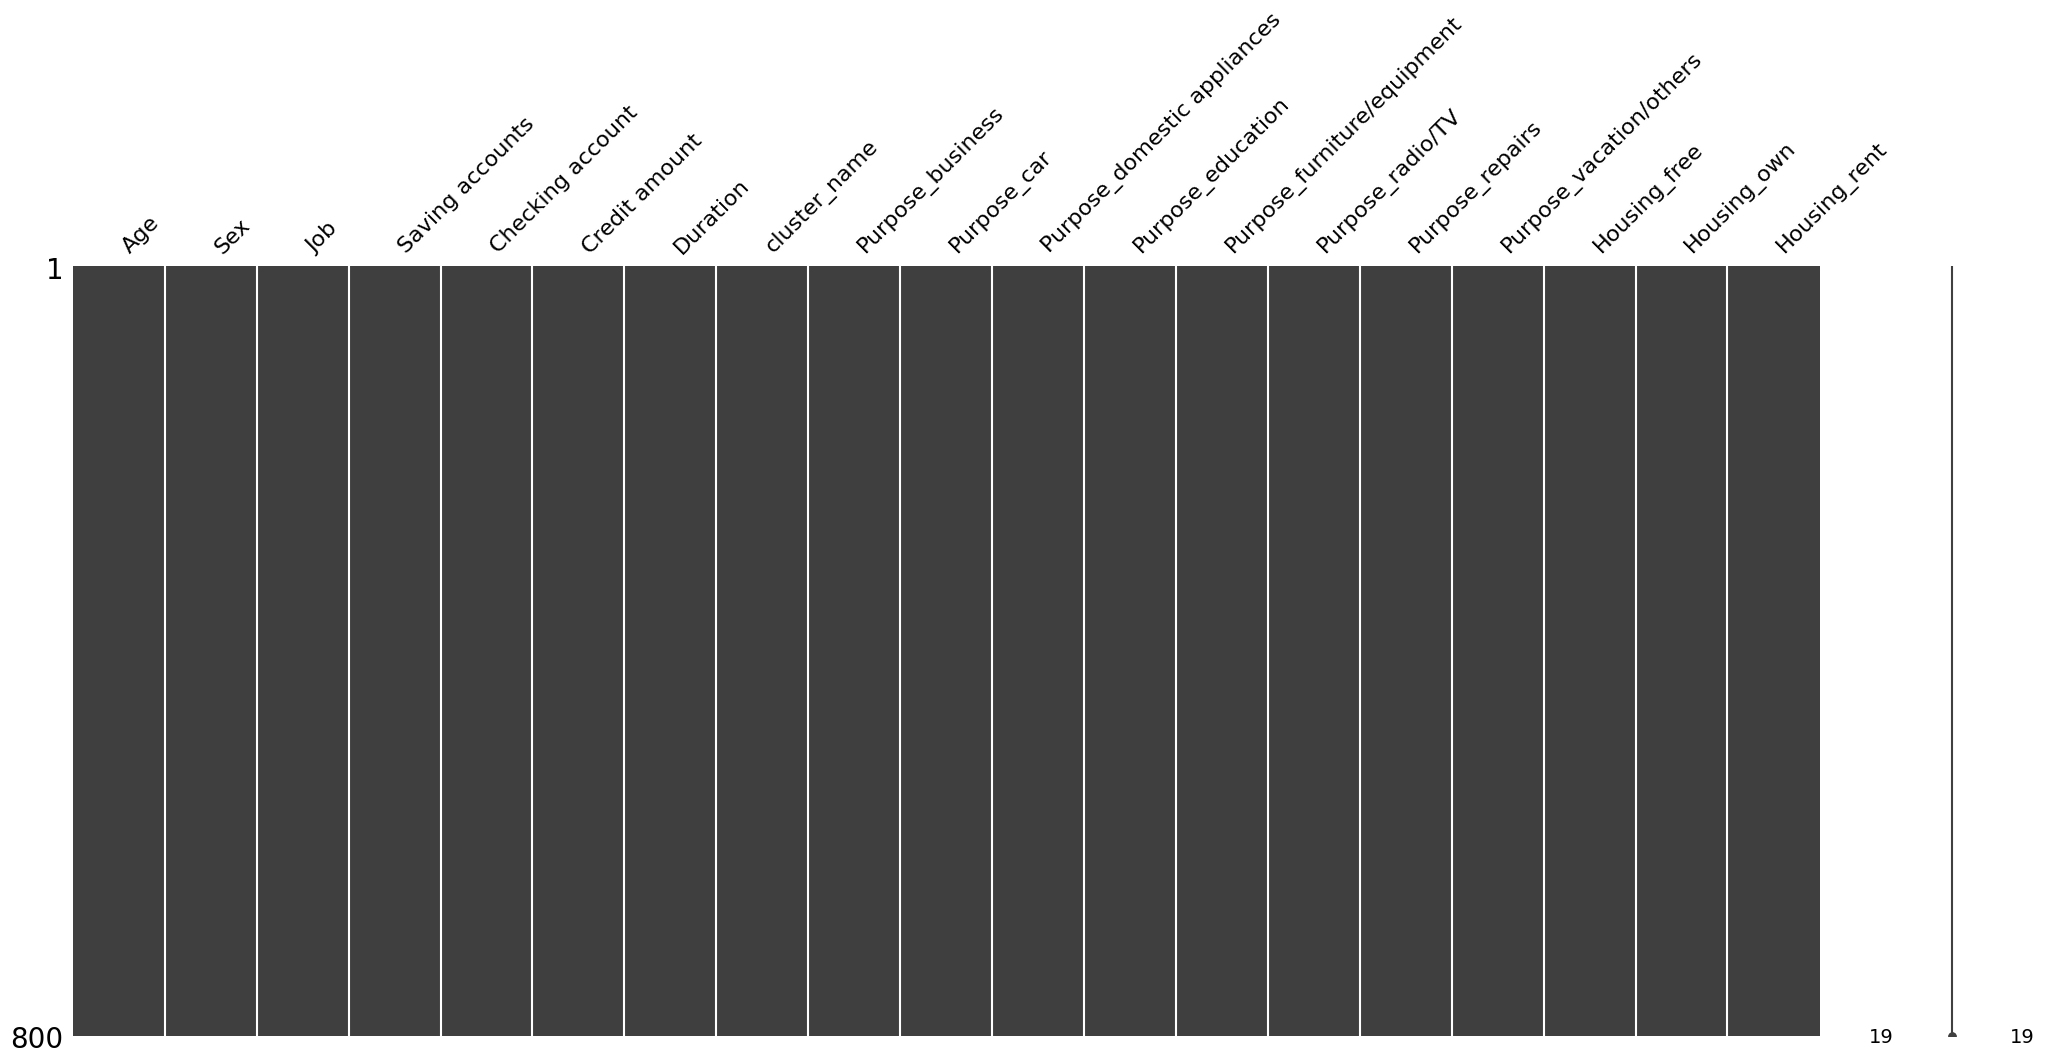

In [179]:
msno.matrix(x_train)
plt.show()

###**Distribution for each numerical feature**

In [180]:
num_cols_x = x_train.select_dtypes(include=np.number).columns

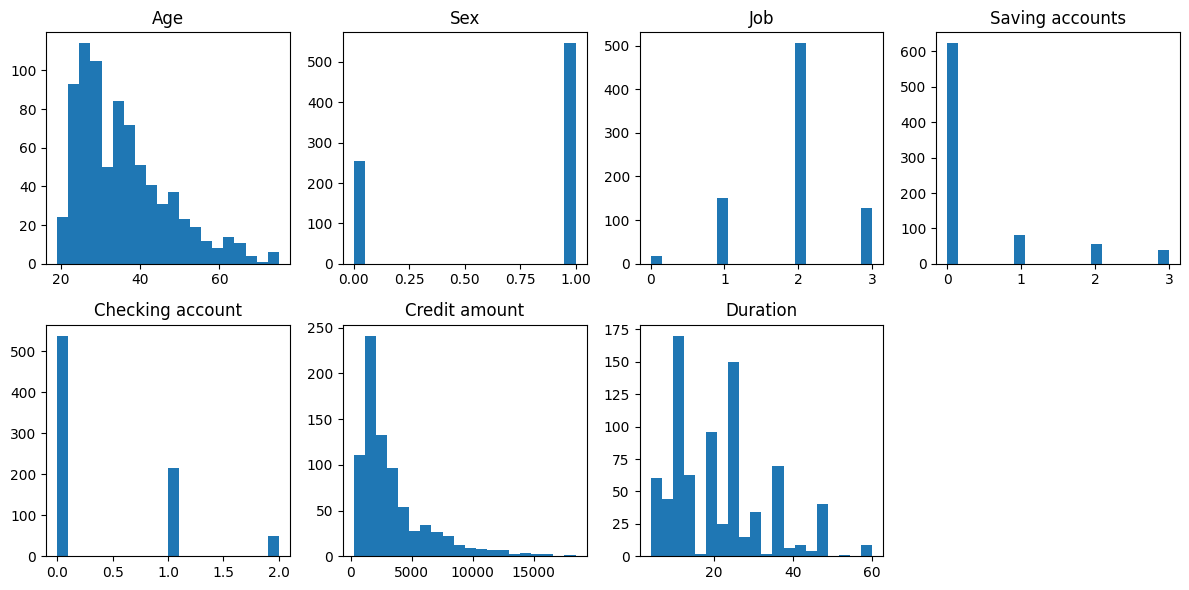

In [181]:
plt.figure(figsize=(12, 6))

for i, c in enumerate(num_cols_x):
    plt.subplot(2, (len(num_cols_x)+1)//2, i+1)
    plt.hist(x_train[c].dropna(), bins=20)
    plt.title(c)

plt.tight_layout()
plt.show()

###**Applying log transformation to reduce skeweness**

In [182]:
x_train["Age"] = np.log(x_train["Age"] + 1)
x_train["Credit amount"] = np.log(x_train["Credit amount"] + 1)
x_train["Duration"] = np.log(x_train["Duration"] + 1)

In [183]:
x_test["Age"] = np.log(x_test["Age"] + 1)
x_test["Credit amount"] = np.log(x_test["Credit amount"] + 1)
x_test["Duration"] = np.log(x_test["Duration"] + 1)

###**Checking Histogram after transformation**

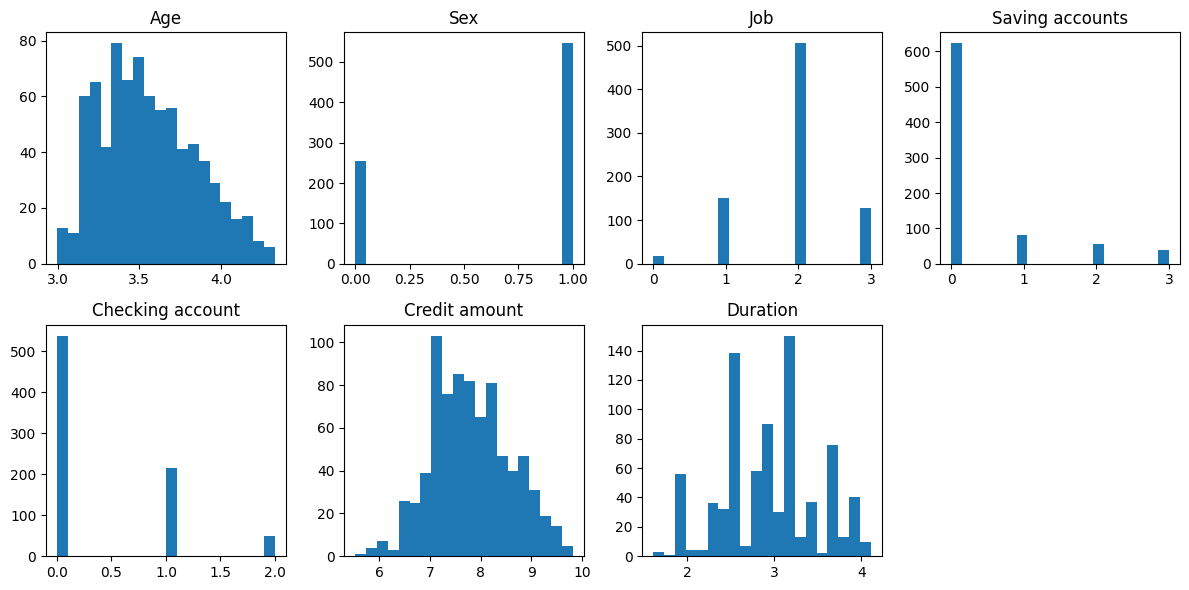

In [184]:
plt.figure(figsize=(12, 6))

for i, c in enumerate(num_cols_x):
    plt.subplot(2, (len(num_cols_x)+1)//2, i+1)
    plt.hist(x_train[c].dropna(), bins=20)
    plt.title(c)

plt.tight_layout()
plt.show()

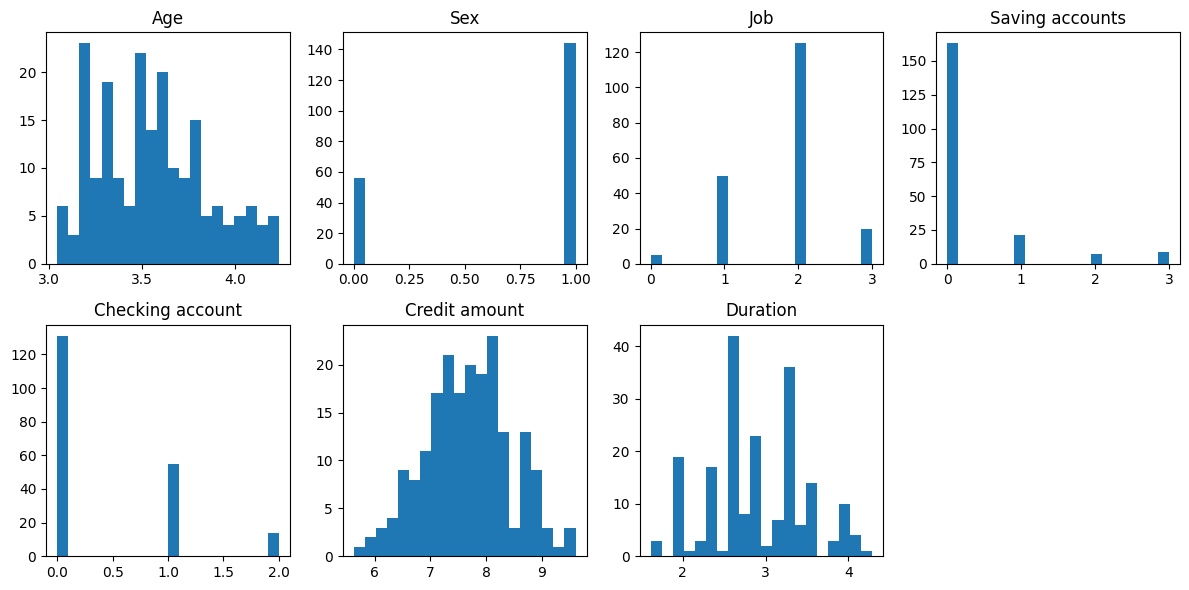

In [185]:
plt.figure(figsize=(12, 6))

for i, c in enumerate(num_cols_x):
    plt.subplot(2, (len(num_cols_x)+1)//2, i+1)
    plt.hist(x_test[c].dropna(), bins=20)
    plt.title(c)

plt.tight_layout()
plt.show()

###**Feature Scaling**

In [186]:
scale_cols = ["Age", "Credit amount", "Duration"]
scaler = StandardScaler()
x_train[scale_cols] = scaler.fit_transform(x_train[scale_cols])

In [187]:
x_test[scale_cols] = scaler.transform(x_test[scale_cols])

##**Modeling**

###**Logistic Regression Model**

In [188]:
x_train = x_train.drop("cluster_name", axis=1)
x_test  = x_test.drop("cluster_name", axis=1)

In [189]:
lr=LogisticRegression()

In [190]:
lr.fit(x_train,y_train)

LogisticRegression()

# Cross Validation

In [197]:
cv_scores = cross_val_score(
    lr,
    x_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("CV scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

CV scores: [0.9375  0.96875 0.95    0.96875 0.9875 ]
Mean CV Accuracy: 0.9625


In [191]:
y_pred=lr.predict(x_test)

###**Accuracy and classification Report of logistic Regression**

In [192]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.96      0.96      0.96        75
           2       0.96      0.98      0.97        53
           3       0.97      0.97      0.97        60

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200



##**Learning Curve**

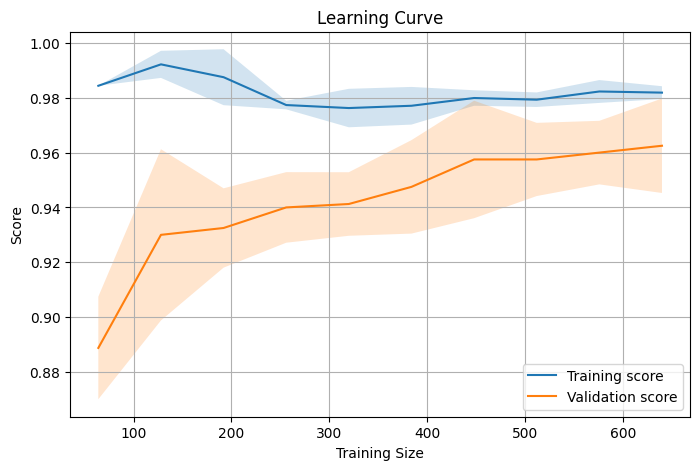

In [193]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=lr,
    X=x_train,
    y=y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)

val_mean = np.mean(val_scores, axis=1)
val_std  = np.std(val_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label='Training score')
plt.plot(train_sizes, val_mean, label='Validation score')

plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.2)

plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.2)

plt.xlabel('Training Size')
plt.ylabel('Score')
plt.title('Learning Curve')
plt.legend()
plt.grid()
plt.show()


# Bias variance decomosition

In [194]:
avg_expected_loss, avg_bias, avg_var = bias_variance_decomp(
        lr, x_train.values, y_train.values, x_test.values, y_test.values,
        loss='0-1_loss',
        num_rounds=200,
        random_seed=42
    )

print(f'Average Expected Loss: {avg_expected_loss:.3f}')
print(f'Average Bias: {avg_bias:.3f}')
print(f'Average Variance: {avg_var:.3f}')

Average Expected Loss: 0.044
Average Bias: 0.040
Average Variance: 0.019
